In [39]:
# Prepping our data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import matplotlib.dates as mdates
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf


In [40]:
bond_yields=pd.read_excel(r'C:\Users\DELL\Desktop\Indian-bond-yield-curve-analysis\Yield Data.xlsx',header=6)
repo = pd.read_excel(r'C:\Users\DELL\Desktop\Indian-bond-yield-curve-analysis\Repo Data.xlsx',sheet_name = 'Monthly')


In [41]:
print('Bond_Yields shape:', bond_yields.shape)
print('Repo rate shape:', repo.shape)
print("\nbond_yields preview:")
print(bond_yields.head())
print("\nrepo preview:")
print(repo.head())

print('Bond_Yields columns:',bond_yields.columns)
print('Repo columns:', repo.columns)

Bond_Yields shape: (120, 32)
Repo rate shape: (120, 2)

bond_yields preview:
   Unnamed: 0 Unnamed: 1    1 Year   2 Years   3 Years   4 Years   5 Years  \
0         NaN   Dec-2025  5.547820  5.809951  5.886644  6.182721  6.394293   
1         NaN   Nov-2025  5.539764  5.781711  5.821506  6.051092  6.255710   
2         NaN   Oct-2025  5.648212  5.682097  5.919457  6.096276  6.245572   
3         NaN   Sep-2025  5.634149  5.831896  5.863432  6.049822  6.244740   
4         NaN   Aug-2025  5.650740  5.808755  6.033923  6.219477  6.376989   

    6 Years   7 Years   8 Years  ...  21 Years  22 Years  23 Years  24 Years  \
0  6.537396  6.619062  6.637057  ...  7.142860  7.166121  7.189383  7.212644   
1  6.403378  6.519390  6.531542  ...  7.102264  7.132350  7.162436  7.182555   
2  6.394219  6.469313  6.586352  ...  7.090272  7.120644  7.151017  7.170262   
3  6.446705  6.532728  6.612073  ...  7.093226  7.119099  7.144973  7.162590   
4  6.515922  6.607781  6.669399  ...  7.131484  7.1738

In [42]:
bond_yields.rename(columns={'Unnamed: 1':'date'}, inplace = True)
bond_yields.drop(columns=['Unnamed: 0'], inplace = True)
repo.rename(columns={'observation_date':'date','INDIRLTLT01STM' : 'repo_rate'}, inplace=True)


In [43]:
bond_yields['date']=pd.to_datetime(bond_yields['date'])
repo['date']=pd.to_datetime(bond_yields['date'])
bond_yields=bond_yields.set_index('date')
repo=repo.set_index('date')

C:\Users\DELL\AppData\Local\Temp\ipykernel_20032\84508781.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  bond_yields['date']=pd.to_datetime(bond_yields['date'])


In [44]:
bond_yields = bond_yields.sort_values('date')
repo=repo.sort_values('date')

In [45]:
bond_yields=bond_yields[['1 Year', '5 Years', '10 Years']]

In [46]:
print(bond_yields.isnull().sum())
print(repo.isnull().sum())

print("\ncolumns in bond yields data:")
print(bond_yields.columns.tolist())

print("\ncolumns in repo data:")
print(repo.columns.tolist())

print(bond_yields.head())
print(repo.head())

print(bond_yields.dtypes)
print(repo.dtypes)

1 Year      0
5 Years     0
10 Years    0
dtype: int64
repo_rate    0
dtype: int64

columns in bond yields data:
['1 Year', '5 Years', '10 Years']

columns in repo data:
['repo_rate']
            1 Year  5 Years  10 Years
date                                 
2016-01-01  7.1885   7.7585    7.5187
2016-02-01  7.2498   7.8748    7.6385
2016-03-01  7.1362   7.6049    7.4025
2016-04-01  7.0513   7.4920    7.8721
2016-05-01  7.3289   7.7368    7.4650
            repo_rate
date                 
2016-01-01     6.6325
2016-02-01     6.5375
2016-03-01     6.4820
2016-04-01     6.5850
2016-05-01     6.5220
1 Year      float64
5 Years     float64
10 Years    float64
dtype: object
repo_rate    float64
dtype: object


In [47]:
print(bond_yields.describe().round(5))
print(repo.describe().round(5))

          1 Year    5 Years   10 Years
count  120.00000  120.00000  120.00000
mean     6.02045    6.73136    6.94782
std      1.18741    0.70499    0.52725
min      3.46100    5.07280    5.69330
25%      5.53059    6.24536    6.58638
50%      6.45800    6.82669    6.99200
75%      6.89761    7.21173    7.36868
max      7.67220    8.15190    8.01260
       repo_rate
count  120.00000
mean     6.91961
std      0.52197
min      5.81452
25%      6.57453
50%      6.95600
75%      7.33773
max      8.01908


In [48]:
print(type(bond_yields.index))
print(bond_yields.index[:5])

print(type(repo.index))
print(repo.index[:2])

repo=repo[repo.index>=bond_yields.index.min()]
repo=repo[repo.index<=bond_yields.index.max()]

<class 'pandas.core.indexes.datetimes.DatetimeIndex'>
DatetimeIndex(['2016-01-01', '2016-02-01', '2016-03-01', '2016-04-01',
               '2016-05-01'],
              dtype='datetime64[ns]', name='date', freq=None)
<class 'pandas.core.indexes.datetimes.DatetimeIndex'>
DatetimeIndex(['2016-01-01', '2016-02-01'], dtype='datetime64[ns]', name='date', freq=None)


In [49]:
#BASIC YIELD CURVE STATISTICS

bond_yields['spread_10yr_1yr']=bond_yields['10 Years'] - bond_yields['1 Year']

print("\nYield Cueve Spread (10yr - 1yr):")

print(f"Average Spread:{bond_yields['spread_10yr_1yr'].mean():.2f}%")

print(f"Minimum Spread:{bond_yields['spread_10yr_1yr'].min():.2f}%")

print(f"Maximum Spread:{bond_yields['spread_10yr_1yr'].max():.2f}%")

print(f" Periods of Inversion (Spread < 0):{(bond_yields['spread_10yr_1yr']<0).sum()} month")



Yield Cueve Spread (10yr - 1yr):
Average Spread:0.93%
Minimum Spread:-0.08%
Maximum Spread:2.69%
 Periods of Inversion (Spread < 0):4 month


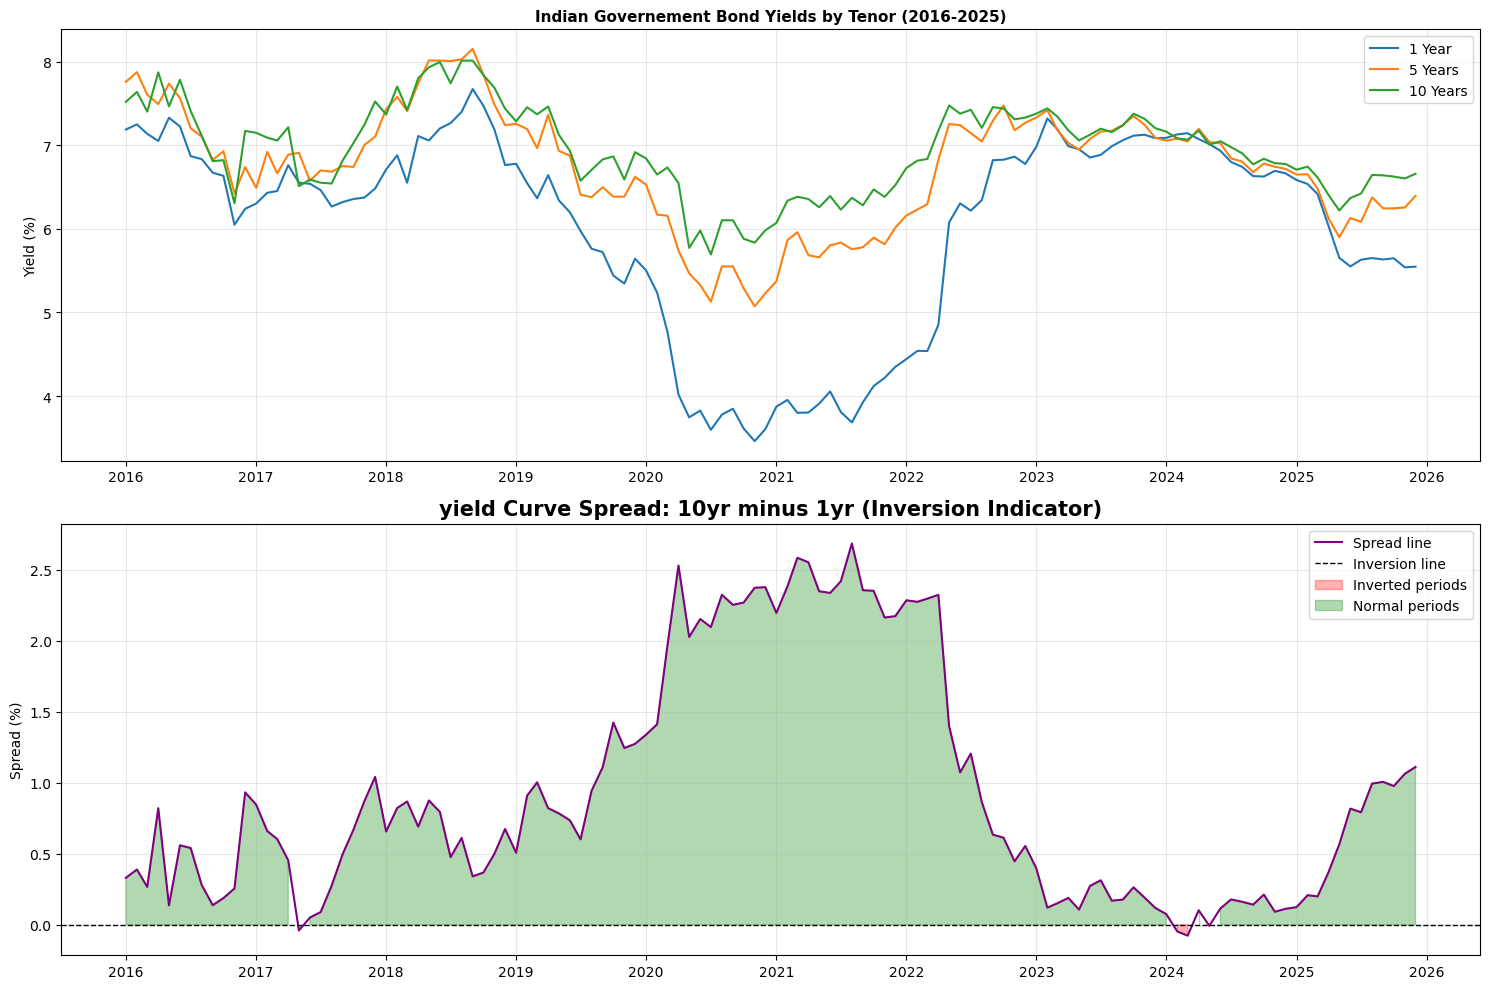

In [50]:
#VISUALISE YIELD CURVE EVOLUTION
fig, axes = plt.subplots(2,1,figsize=(15,10))
ax1=axes[0]
for col in bond_yields.columns:
    if col!='spread_10yr_1yr':
        ax1.plot(bond_yields.index, bond_yields[col], label=col, linewidth = 1.5)
ax1.set_title('Indian Governement Bond Yields by Tenor (2016-2025)', fontsize = 11, fontweight ='bold')
ax1.set_ylabel('Yield (%)')
ax1.legend(loc='best')
ax1.grid(True, alpha = 0.3)  
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax2=axes[1]
ax2.plot(bond_yields.index,bond_yields['spread_10yr_1yr'], color='purple', label= 'Spread line', linewidth=1.5)
ax2.axhline(y=0, color='black',linestyle='--',linewidth=1,label='Inversion line')
ax2.fill_between(bond_yields.index, bond_yields['spread_10yr_1yr'],0, where=(bond_yields['spread_10yr_1yr']<0),
color ='red', alpha=0.3, label='Inverted periods')
ax2.fill_between(bond_yields.index,bond_yields['spread_10yr_1yr'], 0, where=(bond_yields['spread_10yr_1yr']>= 0)
                ,color ='green', alpha = 0.3, label ='Normal periods')

ax2.set_title('yield Curve Spread: 10yr minus 1yr (Inversion Indicator)',
              fontsize = 15,
              fontweight ='bold')
ax2.set_ylabel('Spread (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig(r'C:\Users\DELL\Desktop\Indian-bond-yield-curve-analysis\yield_evolution.png',
dpi = 150, bbox_inches ='tight')
plt.show()

# don't forget to add the save command

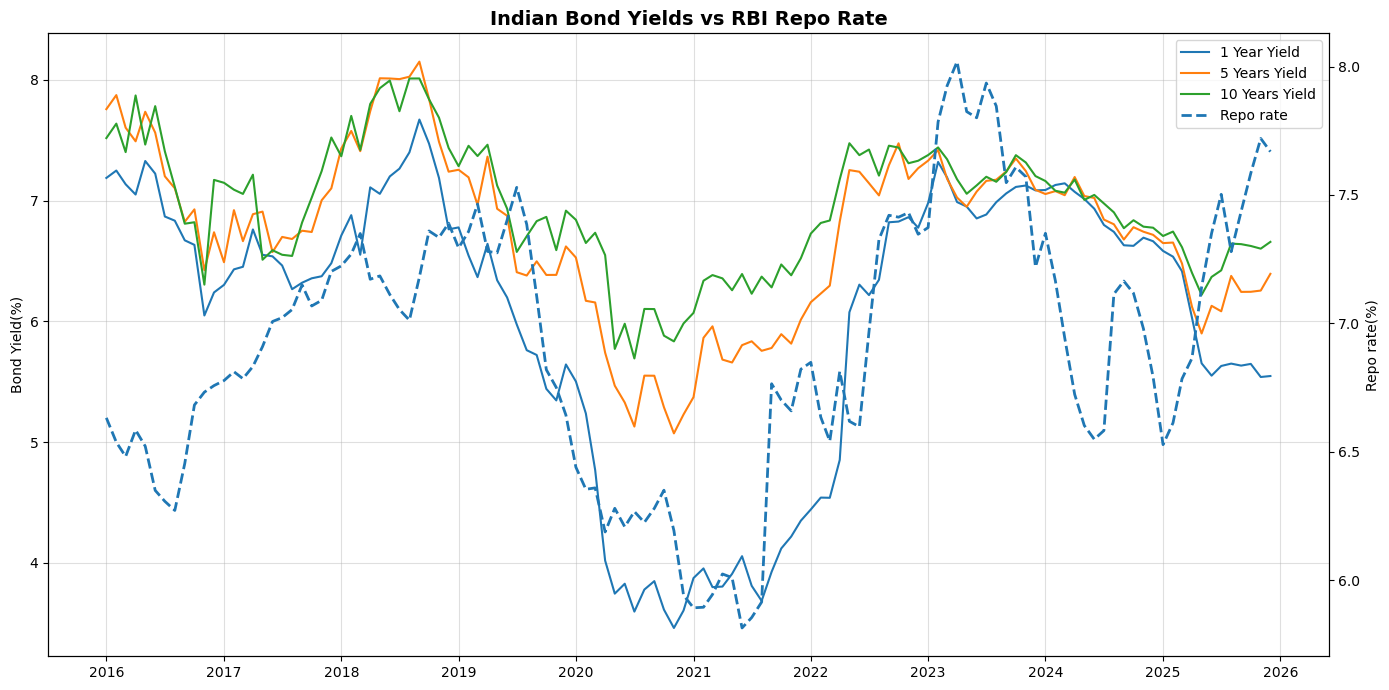

In [51]:
#REPO RATE vs BOND YIELDS

fig,ax1 = plt.subplots(figsize=(14,7))
ax2=ax1.twinx()

ax1.plot(bond_yields.index,bond_yields['1 Year'], label='1 Year Yield',linewidth=1.5)
ax1.plot(bond_yields.index,bond_yields['5 Years'], label='5 Years Yield',linewidth=1.5)
ax1.plot(bond_yields.index,bond_yields['10 Years'], label='10 Years Yield',linewidth=1.5)

ax2.plot(repo.index,repo['repo_rate'], label='Repo rate',linewidth=2, linestyle='--')

ax1.set_ylabel('Bond Yield(%)')
ax2.set_ylabel('Repo rate(%)')

ax1.set_title('Indian Bond Yields vs RBI Repo Rate', fontsize=14,fontweight='bold')

lines1,labels1 = ax1.get_legend_handles_labels()
lines2,labels2=ax2.get_legend_handles_labels()

ax1.legend(lines1+lines2, labels1+labels2,loc='best')
ax1.grid(True, alpha = 0.4)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()


--- CORRELATION WITH REPO RATE ---
             1 Year   5 Years  10 Years  repo_rate
1 Year     1.000000  0.913164  0.819800   0.617196
5 Years    0.913164  1.000000  0.954451   0.515132
10 Years   0.819800  0.954451  1.000000   0.468993
repo_rate  0.617196  0.515132  0.468993   1.000000

1-Year Yield:0.617

5-Year Yield:0.515

10-Year Yield:0.469


<Axes: >

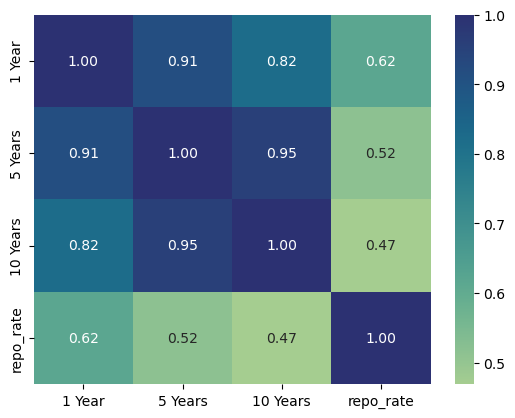

In [52]:
#REPO RATE AND YIELD CORRELATION

merged = bond_yields.join(repo,how='inner')

print("\n--- CORRELATION WITH REPO RATE ---")

correlation_matrix=merged[['1 Year', '5 Years', '10 Years','repo_rate']].corr()
print(correlation_matrix)

print(f"\n1-Year Yield:{correlation_matrix.loc['1 Year','repo_rate']:.3f}")
print(f"\n5-Year Yield:{correlation_matrix.loc['5 Years','repo_rate']:.3f}")
print(f"\n10-Year Yield:{correlation_matrix.loc['10 Years','repo_rate']:.3f}")

sns.heatmap(correlation_matrix,annot=True,cmap='crest',fmt='.2f')


In [53]:
# STATIONARITY TEST (ADF TEST)
print('\nStationarity test(ADF Test)')
print("Null Hypothesis: Series has a unit root (non-stationary)")
print("If p-value < 0.05: Reject null - series is stationary")
print("If p-value > 0.05:Fail to reject null - series is not stationary")

def adf_test(series,name):
    result=adfuller(series.dropna())
    print(f"ADF Statistics:{result[0]:.4f}")
    print(f"p-value:{result[1]:.4f}")
    print(f"conclusion:{'Stationary' if result[1]<0.05 else'Non-Stationary'}")
    print()
    return result[1]

p_level=adf_test(bond_yields['10 Years'], '10 Years Yield (levels)')

bond_yields['10yr_diff']=bond_yields['10 Years'].diff()
p_diff=adf_test(bond_yields['10yr_diff'], '10yr Yield (First Difference)')

with open(r'C:\Users\DELL\Desktop\Indian-bond-yield-curve-analysis\adf_test_results.txt', 'w') as f:
   f.write('ADF Test results\n')
   f.write(f"10yr Yield (levels) p-value:{p_level}\n")
   f.write(f"conclusion: {'Stationary' if p_level < 0.05 else 'Non-Stationary'}\n\n")
   f.write(f"10yr Yield (first Difference) p_value:{p_diff}\n")
   f.write(f"conclusion: {'Stationary' if p_diff < 0.05 else 'Non-Stationary'}\n")


Stationarity test(ADF Test)
Null Hypothesis: Series has a unit root (non-stationary)
If p-value < 0.05: Reject null - series is stationary
If p-value > 0.05:Fail to reject null - series is not stationary
ADF Statistics:-2.4513
p-value:0.1278
conclusion:Non-Stationary

ADF Statistics:-3.9450
p-value:0.0017
conclusion:Stationary



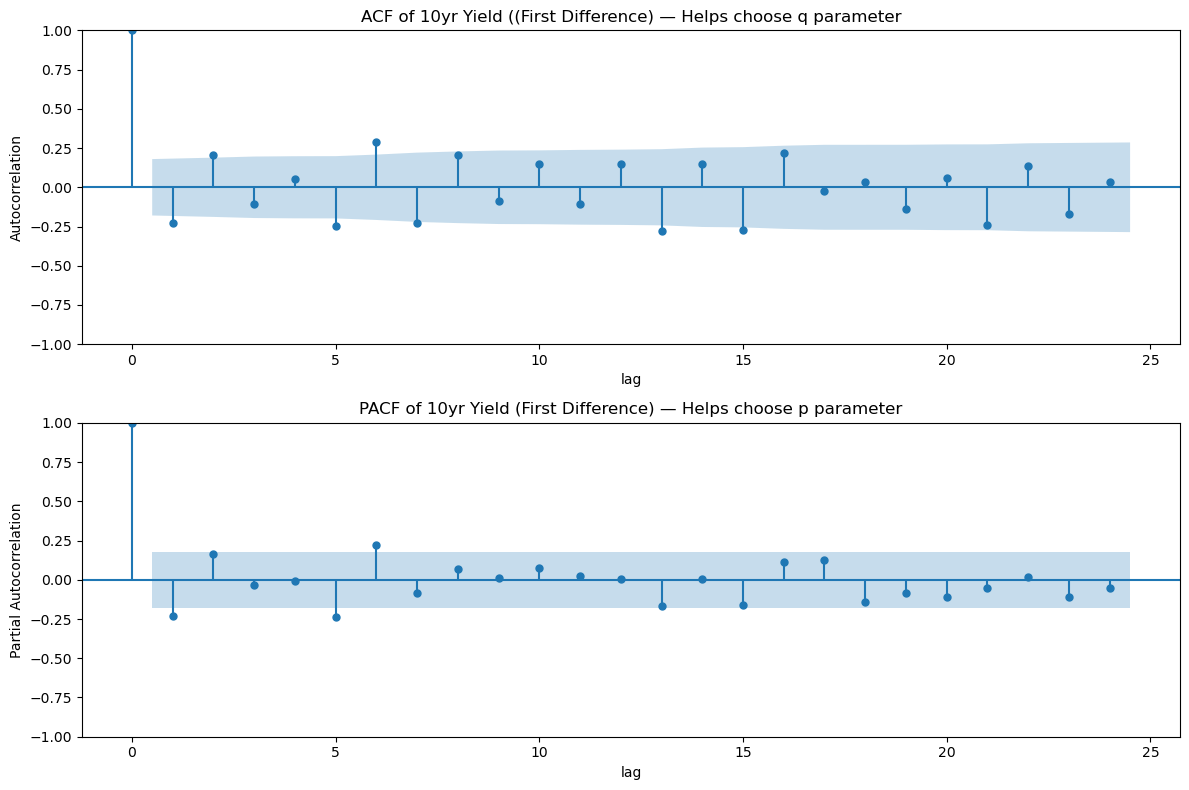

In [54]:
fig,axes=plt.subplots(2,1,figsize=(12,8))

ax1=axes[0]
ax2=axes[1]

plot_acf(bond_yields['10yr_diff'].dropna(), lags=24,ax=ax1)
ax1.set_title('ACF of 10yr Yield ((First Difference) — Helps choose q parameter')

plot_pacf(bond_yields['10yr_diff'].dropna(),lags=24,ax=ax2)
ax2.set_title('PACF of 10yr Yield (First Difference) — Helps choose p parameter')

ax1.set_xlabel('lag')
ax2.set_xlabel('lag')

ax1.set_ylabel('Autocorrelation')
ax2.set_ylabel('Partial Autocorrelation')

plt.tight_layout()
plt.savefig(r'C:\Users\DELL\Desktop\Indian-bond-yield-curve-analysis\acf_pacf.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [55]:
train_size = int(len(bond_yields)*0.8)
train = bond_yields['10 Years'][:train_size]
test=bond_yields['10 Years'][train_size:]

print(f"Training period:{train.index[0].strftime('%Y-%m')} to {train.index[-1].strftime('%Y-%m')}")
print(f"Testing Period:{test.index[0].strftime('%Y-%m')}to {test.index[-1].strftime('%Y-%m')}")

print(f"Training Samples:{len(train)}")
print(f"Testing Samples:{len(test)}")

model=ARIMA(train, order=(1,1,1))

fitted_model=model.fit()

print("ARIMA Model Summary:")
print(fitted_model.summary())


Training period:2016-01 to 2023-12
Testing Period:2024-01to 2025-12
Training Samples:96
Testing Samples:24
ARIMA Model Summary:
                               SARIMAX Results                                
Dep. Variable:               10 Years   No. Observations:                   96
Model:                 ARIMA(1, 1, 1)   Log Likelihood                   7.829
Date:                Wed, 29 Jul 2026   AIC                             -9.658
Time:                        22:05:50   BIC                             -1.997
Sample:                    01-01-2016   HQIC                            -6.562
                         - 12-01-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9937      0.009   -108.431      0.000      -1.012      -0.976
ma.

D:\Users\DELL\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
D:\Users\DELL\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
D:\Users\DELL\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [56]:
forecast = fitted_model.forecast(steps=len(test))
forecast_index = test.index

mae=np.mean(np.abs(forecast.values-test.values))
rmse=np.sqrt(np.mean((forecast.values-test.values)**2))
mape=np.mean(np.abs((forecast.values-test.values)/test.values))*100

print("\n--- FORECAST ACCURACY ---")
print(f"MAE  (Mean Absolute Error): {mae:.2f}%")
print(f"RMSE (Root Mean Square Error): {rmse:.2f}%")
print(f"MAPE (Mean Absolute Percentage Error): {mape:.2f}%")


--- FORECAST ACCURACY ---
MAE  (Mean Absolute Error): 0.44%
RMSE (Root Mean Square Error): 0.51%
MAPE (Mean Absolute Percentage Error): 6.65%


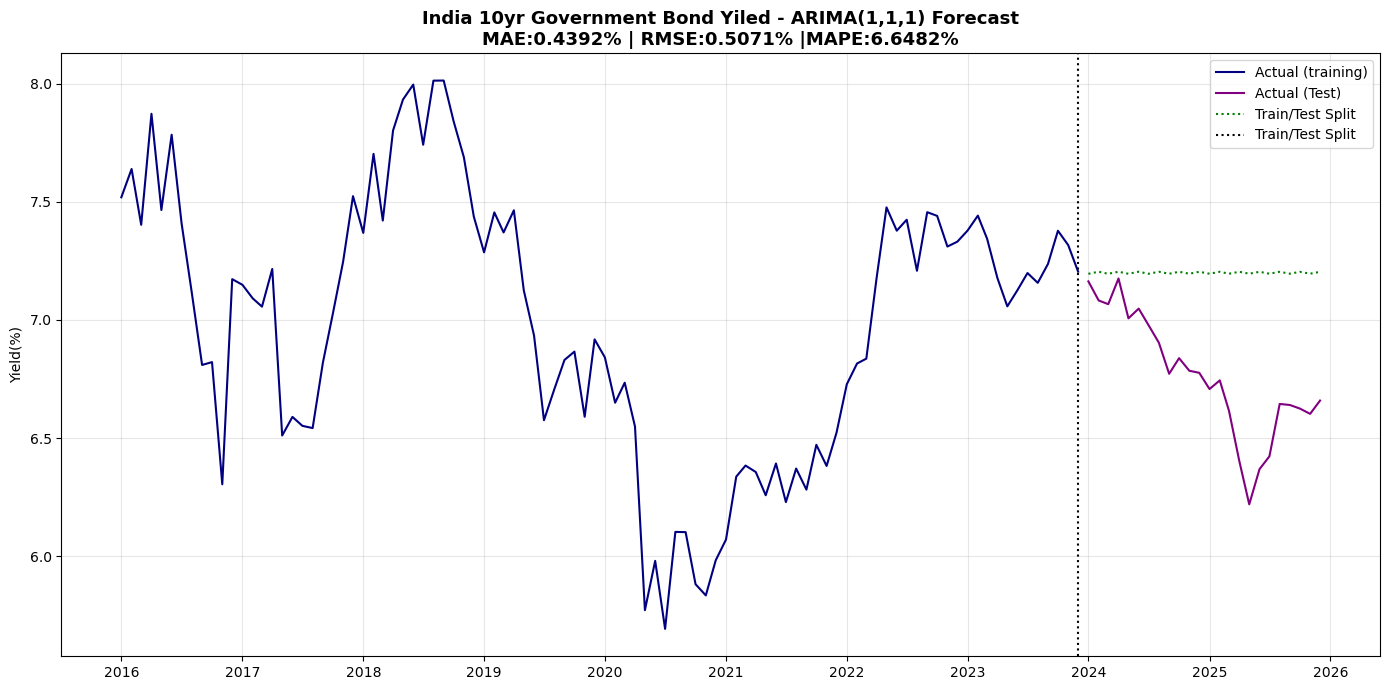

In [57]:
fig,ax=plt.subplots(figsize=(14,7))
ax.plot(train.index,train,color='navy',linewidth=1.5,label='Actual (training)')
ax.plot(test.index, test, color='purple', linewidth=1.5,label='Actual (Test)')

ax.plot(forecast_index, forecast, color='green', linewidth=1.5, linestyle=':', label='Train/Test Split')

ax.axvline(x=train.index[-1], color ='black',linestyle=':',linewidth=1.5,label='Train/Test Split')

ax.set_title(f"India 10yr Government Bond Yiled - ARIMA(1,1,1) Forecast\nMAE:{mae:.4f}% | RMSE:{rmse:.4f}% |MAPE:{mape:.4f}%",fontsize= 13, fontweight='bold')
ax.set_ylabel('Yield(%)')
ax.grid(True, alpha=0.3)
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig(r'C:\Users\DELL\Desktop\Indian-bond-yield-curve-analysis\arima_forecast.png',
            dpi=150, bbox_inches='tight')
plt.show()

D:\Users\DELL\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
D:\Users\DELL\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
D:\Users\DELL\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\DELL\AppData\Local\Temp\ipykernel_20032\1633503140.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(start=bond_yields.index[-1], periods = 13, freq='M')[1:]
C:\Users\DELL\AppData\Local\Temp\ipykernel_20032\1633503140.py:11: FutureWarning: last is deprecated and will be removed in a future

         date  forecasted_10yr_yield
0  2026-01-31                   6.62
1  2026-02-28                   6.66
2  2026-03-31                   6.62
3  2026-04-30                   6.66
4  2026-05-31                   6.62
5  2026-06-30                   6.66
6  2026-07-31                   6.62
7  2026-08-31                   6.66
8  2026-09-30                   6.62
9  2026-10-31                   6.66
10 2026-11-30                   6.62
11 2026-12-31                   6.66


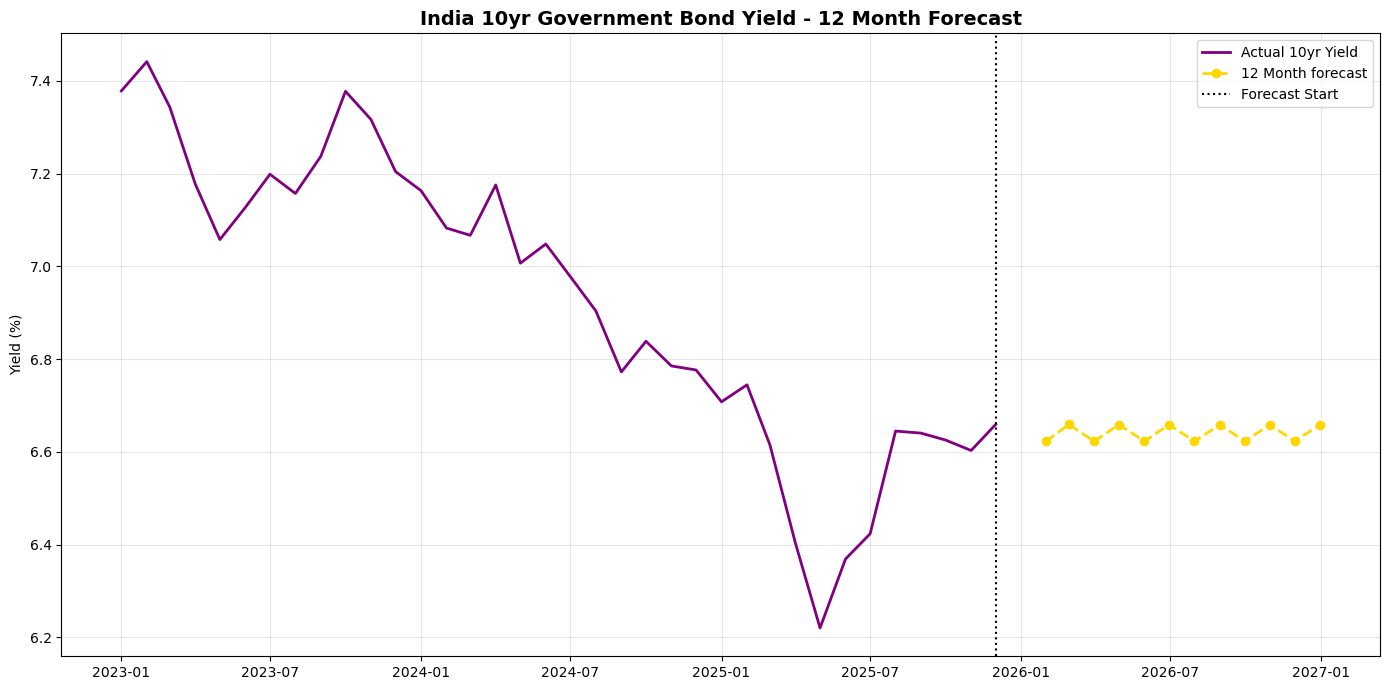

In [58]:
full_model = ARIMA(bond_yields['10 Years'], order = (1,1,1))
full_fitted = full_model.fit()

future_forecast= full_fitted.forecast(steps=12)
future_dates = pd.date_range(start=bond_yields.index[-1], periods = 13, freq='M')[1:]

forecast_df = pd.DataFrame({'date': future_dates,'forecasted_10yr_yield': future_forecast.values.round(2)})
print(forecast_df)

fig,ax=plt.subplots(figsize=(14,7))
recent = bond_yields['10 Years'].last('36M')

ax.plot(recent.index,recent,color='purple',linewidth=2,label='Actual 10yr Yield')
ax.plot(future_dates,future_forecast,color='gold',linewidth=2,linestyle='--',label='12 Month forecast',marker='o')
ax.axvline(x=bond_yields.index[-1],color='black',linestyle=':', linewidth=1.5,label='Forecast Start')

ax.set_title('India 10yr Government Bond Yield - 12 Month Forecast', fontsize=14, fontweight='bold')
ax.set_ylabel('Yield (%)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.tight_layout()
plt.savefig(r'C:\Users\DELL\Desktop\Indian-bond-yield-curve-analysis\future_forecast.png',
            dpi=150, bbox_inches='tight')
plt.show()
